In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Preliminary Questions

#### Describe the dataset

* The data.csv dataset contains job market data from various locations within Australia

* Numerical, Categorical, Ordinal, and Discrete data can be seen within the dataset, due to the
    diverse range of classifiers. 13-columns are used to represent a single job, containing key 
    information such as; Company, Location, Description, Salary etc.
    
* The data follows a tabular format, having structured rows and columns with cells that inform
    the relationship between them.
    
* Valuable attributes such as Salary range, Job Classification, and 
    Location will sections of interest for analysis on the dataset.
    
* What parts of the dataset will we use? (Answer once started)

#### Data preparation and preprocessing

* To load the data.csv file into the program, we will make use of the Pandas library.
    1) Import the library using "import pandas as pd"
    2) Use the open_csv() pandas function to import the .csv file. "df = pd.read_csv("data.csv")".
        The .csv file object will be assigned to the variable "df"
        
* Data normalization is important as the same data can be represented in varying formats.
    ***EDIT - We will need to normalise dates, and clean NaN cells found in columns of no use (need to expand more)

#### Hypothesis


* (Honestly not too sure what to write here at this point in time)


# Part 1 - Data Preparation and Preprocessing

### Load datatset
* Categories/domains 
* Data types



In [14]:
df = pd.read_csv("data.csv")
df.head()

C:\Users\James\AppData\Local\Temp\ipykernel_27932\2036481670.py:1: DtypeWarning: Columns (0,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv")


,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType
0,37404348,Casual Stock Replenisher,Aldi Stores,2018-10-07T00:00:00.000Z,Sydney,North West & Hills District,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
1,37404337,Casual Stock Replenisher,Aldi Stores,2018-10-07T00:00:00.000Z,Richmond & Hawkesbury,NaN,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
2,37404356,RETAIL SALES SUPERSTARS and STYLISTS Wanted - ...,LB Creative Pty Ltd,2018-10-07T00:00:00.000Z,Brisbane,CBD & Inner Suburbs,Retail & Consumer Products,Retail Assistants,BRAND NEW FLAGSHIP STORE OPENING - SUNSHINE PLAZA,NaN,0,30,NaN
3,37404330,Team member - Belrose,Anaconda Group Pty Ltd,2018-10-07T00:00:00.000Z,Gosford & Central Coast,NaN,Retail & Consumer Products,Retail Assistants,Bring it on - do you love the great outdoors a...,NaN,0,30,NaN
4,37404308,"Business Banking Contact Centre Specialist, Ni...",Commonwealth Bank - Business & Private Banking,2018-10-07T00:00:00.000Z,Sydney,Ryde & Macquarie Park,Call Centre & Customer Service,Sales - Inbound,"We are seeking highly articulate, enthusiastic...",NaN,0,30,NaN


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df.dtypes

Id                   object
Title                object
Company              object
Date                 object
Location             object
Area                 object
Classification       object
SubClassification    object
Requirement          object
FullDescription      object
LowestSalary          int64
HighestSalary         int64
JobType              object
dtype: object

In [5]:
df.size
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318477 entries, 0 to 318476
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Id                 318477 non-null  object             
 1   Title              318477 non-null  object             
 2   Company            306473 non-null  object             
 3   Date               318477 non-null  datetime64[ns, UTC]
 4   Location           197229 non-null  object             
 5   Area               122658 non-null  object             
 6   Classification     197229 non-null  object             
 7   SubClassification  197229 non-null  object             
 8   Requirement        318470 non-null  object             
 9   FullDescription    302302 non-null  object             
 10  LowestSalary       318477 non-null  int64              
 11  HighestSalary      318477 non-null  int64              
 12  JobType            302379 non-

Location, Area, Classification, SubClassification appear to have 30% NaN values

In [6]:
#print all columns of dataset
print("Categories: \n\n", df.columns)

print("\n\nSize of each variation of categories:\n")
for row in df:
    print(row, "size: ", df[row].unique().size)


Categories: 

 Index(['Id', 'Title', 'Company', 'Date', 'Location', 'Area', 'Classification',
       'SubClassification', 'Requirement', 'FullDescription', 'LowestSalary',
       'HighestSalary', 'JobType'],
      dtype='object')


Size of each variation of categories:

Id size:  318477
Title size:  168065
Company size:  40629
Date size:  163
Location size:  66
Area size:  20
Classification size:  31
SubClassification size:  339
Requirement size:  234288
FullDescription size:  250902
LowestSalary size:  11
HighestSalary size:  11
JobType size:  5


### Handle Missing Data


In [7]:
print("Before:\n")
df.info()
# drop all rows with NaN values in every column
df.dropna(how='all', inplace=True)
print("\nAfter:\n")
df.info()

Before:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318477 entries, 0 to 318476
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Id                 318477 non-null  object             
 1   Title              318477 non-null  object             
 2   Company            306473 non-null  object             
 3   Date               318477 non-null  datetime64[ns, UTC]
 4   Location           197229 non-null  object             
 5   Area               122658 non-null  object             
 6   Classification     197229 non-null  object             
 7   SubClassification  197229 non-null  object             
 8   Requirement        318470 non-null  object             
 9   FullDescription    302302 non-null  object             
 10  LowestSalary       318477 non-null  int64              
 11  HighestSalary      318477 non-null  int64              
 12  JobType            30

Was found that no NaN rows exist

#### "Locations" with and without NaN values

In [8]:
# find how many locations have all NaN values in Area column
df[df['Area'].isnull()]['Location'].nunique()
print("Number of locations with all NaN values in Area column:", df[df['Area'].isnull()]['Location'].nunique())
# find how many locations have all non NaN values in Area column and print them
areaLocations = df[df['Area'].notnull()]['Location'].nunique()
print("Number of locations with all non NaN values in Area column:", areaLocations)
print("Locations with all non NaN values in Area column:", df[df['Area'].notnull()]['Location'].unique())


Number of locations with all NaN values in Area column: 65
Number of locations with all non NaN values in Area column: 4
Locations with all non NaN values in Area column: ['Sydney' 'Brisbane' 'Melbourne' 'Perth']


### Normalise Formats


Normalise Date

In [9]:
#explore data types in Date column
df['Date'].head()

0   2018-10-07 00:00:00+00:00
1   2018-10-07 00:00:00+00:00
2   2018-10-07 00:00:00+00:00
3   2018-10-07 00:00:00+00:00
4   2018-10-07 00:00:00+00:00
Name: Date, dtype: datetime64[ns, UTC]

0   2018-10-07 00:00:00+00:00
1   2018-10-07 00:00:00+00:00
2   2018-10-07 00:00:00+00:00
3   2018-10-07 00:00:00+00:00
4   2018-10-07 00:00:00+00:00
Name: Date, dtype: datetime64[ns, UTC]

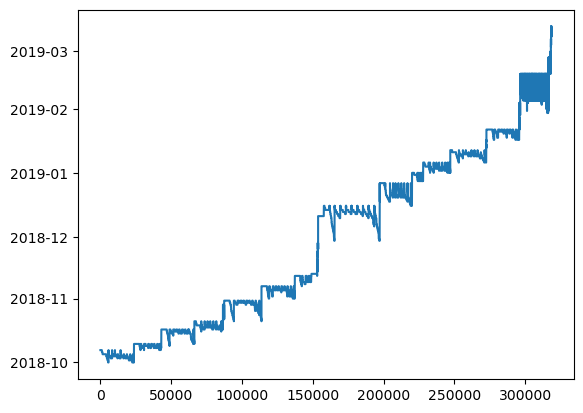

In [10]:
#normalise the data in Date column
df["Date"] = df["Date"].replace(to_replace=r'T.*', value='', regex=True)
df['Date'] = pd.to_datetime(df['Date'])
#visualise Date column in plot
df['Date'].plot()
df['Date'].head()


In [11]:
df.dtypes

Id                                object
Title                             object
Company                           object
Date                 datetime64[ns, UTC]
Location                          object
Area                              object
Classification                    object
SubClassification                 object
Requirement                       object
FullDescription                   object
LowestSalary                       int64
HighestSalary                      int64
JobType                           object
dtype: object

### Remove Duplicates

In [16]:
#check for duplicates in df dataframe
print("Dataframe duplicates: ", df.duplicated().sum())
for row in df:
    print(row, " column duplicates: ", df[row].duplicated().sum())


Dataframe duplicates:  0
Id  column duplicates:  0
Title  column duplicates:  150412
Company  column duplicates:  277848
Date  column duplicates:  318314
Location  column duplicates:  318411
Area  column duplicates:  318457
Classification  column duplicates:  318446
SubClassification  column duplicates:  318138
Requirement  column duplicates:  84189
FullDescription  column duplicates:  67575
LowestSalary  column duplicates:  318466
HighestSalary  column duplicates:  318466
JobType  column duplicates:  318472


* No dataset row duplicates found 

### Change type of related columns

In [47]:
#check Id column for non integer values
print(df['Id'].apply(lambda x: isinstance(x, int)).sum())
print(len(df['Id']))

187405
318477


In [48]:
print(df['Id'][187405:].head(10))

187405    37922161&searchrequesttoken=2a17e27a-d532-470c...
187406    37922151&searchrequesttoken=2a17e27a-d532-470c...
187407    37922143&searchrequesttoken=2a17e27a-d532-470c...
187408    37922140&searchrequesttoken=16638339-1741-4903...
187409    37922135&searchrequesttoken=16638339-1741-4903...
187410    37922127&searchrequesttoken=16638339-1741-4903...
187411    37922104&searchrequesttoken=16638339-1741-4903...
187412    37922099&searchrequesttoken=16638339-1741-4903...
187413    37922085&searchrequesttoken=16638339-1741-4903...
187414    37922055&searchrequesttoken=16638339-1741-4903...
Name: Id, dtype: object


Many invalid Id entries found

In [49]:
#remove the remaining non integer values from each Id column once detected
df['Id'] = df['Id'].apply(lambda x: int(str(x).split('&')[0]))
df.head()

,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType
0,37404348,Casual Stock Replenisher,Aldi Stores,2018-10-07,Sydney,North West & Hills District,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
1,37404337,Casual Stock Replenisher,Aldi Stores,2018-10-07,Richmond & Hawkesbury,NaN,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
2,37404356,RETAIL SALES SUPERSTARS and STYLISTS Wanted - ...,LB Creative Pty Ltd,2018-10-07,Brisbane,CBD & Inner Suburbs,Retail & Consumer Products,Retail Assistants,BRAND NEW FLAGSHIP STORE OPENING - SUNSHINE PLAZA,NaN,0,30,NaN
3,37404330,Team member - Belrose,Anaconda Group Pty Ltd,2018-10-07,Gosford & Central Coast,NaN,Retail & Consumer Products,Retail Assistants,Bring it on - do you love the great outdoors a...,NaN,0,30,NaN
4,37404308,"Business Banking Contact Centre Specialist, Ni...",Commonwealth Bank - Business & Private Banking,2018-10-07,Sydney,Ryde & Macquarie Park,Call Centre & Customer Service,Sales - Inbound,"We are seeking highly articulate, enthusiastic...",NaN,0,30,NaN


In [50]:
#check Id column for non integer values
print(df['Id'].apply(lambda x: isinstance(x, int)).sum())
print(len(df['Id']))

318477
318477


In [51]:
print(df['Id'][187405:].head(10))

187405    37922161
187406    37922151
187407    37922143
187408    37922140
187409    37922135
187410    37922127
187411    37922104
187412    37922099
187413    37922085
187414    37922055
Name: Id, dtype: int64


In [52]:
#check for duplicate Id values
print(df['Id'].duplicated().sum())
#drop duplicate Id values
df.drop_duplicates(subset='Id', inplace=True)
print(df['Id'].duplicated().sum())

14165
0


In [53]:
df["Id"] = df["Id"].astype(np.int64)
df.dtypes


Id                            int64
Title                        object
Company                      object
Date                 datetime64[ns]
Location                     object
Area                         object
Classification               object
SubClassification            object
Requirement                  object
FullDescription              object
LowestSalary                  int64
HighestSalary                 int64
JobType                      object
dtype: object

### Calculate average salary

In [54]:
df = df.assign(AverageSalary = (df['LowestSalary'] + df['HighestSalary'])/2)
df.head()

,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType,AverageSalary
0,37404348,Casual Stock Replenisher,Aldi Stores,2018-10-07,Sydney,North West & Hills District,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN,15.0
1,37404337,Casual Stock Replenisher,Aldi Stores,2018-10-07,Richmond & Hawkesbury,NaN,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN,15.0
2,37404356,RETAIL SALES SUPERSTARS and STYLISTS Wanted - ...,LB Creative Pty Ltd,2018-10-07,Brisbane,CBD & Inner Suburbs,Retail & Consumer Products,Retail Assistants,BRAND NEW FLAGSHIP STORE OPENING - SUNSHINE PLAZA,NaN,0,30,NaN,15.0
3,37404330,Team member - Belrose,Anaconda Group Pty Ltd,2018-10-07,Gosford & Central Coast,NaN,Retail & Consumer Products,Retail Assistants,Bring it on - do you love the great outdoors a...,NaN,0,30,NaN,15.0
4,37404308,"Business Banking Contact Centre Specialist, Ni...",Commonwealth Bank - Business & Private Banking,2018-10-07,Sydney,Ryde & Macquarie Park,Call Centre & Customer Service,Sales - Inbound,"We are seeking highly articulate, enthusiastic...",NaN,0,30,NaN,15.0


### Counts for Unique values in columns


#### Classification column

In [55]:
#Print value counts for each unique value in each column.
print("Value counts for Classification column:", df['Classification'].value_counts())


Value counts for Classification column: Information & Communication Technology    21024
Trades & Services                         16884
Healthcare & Medical                      15771
Hospitality & Tourism                     14360
Manufacturing, Transport & Logistics      11570
Administration & Office Support            9464
Accounting                                 8698
Education & Training                       8603
Construction                               7738
Sales                                      7561
Retail & Consumer Products                 7558
Government & Defence                       7108
Engineering                                5909
Mining, Resources & Energy                 5801
Banking & Financial Services               4311
Community Services & Development           4222
Human Resources & Recruitment              3890
Legal                                      3837
Call Centre & Customer Service             3725
Marketing & Communications                 3718


#### SubClassification column

In [56]:
print("Value counts for SubClassification column:", df['SubClassification'].value_counts())

Value counts for SubClassification column: Other                         10618
Management                     5826
Administrative Assistants      4323
Chefs/Cooks                    4214
Developers/Programmers         3856
                              ...  
Computer Operators               13
Illustration & Animation         13
Air Force                        12
Chiropractic & Osteopathic       10
Army                              4
Name: SubClassification, Length: 338, dtype: int64


#### Location column

In [57]:
print("Value counts for Location column:", df['Location'].value_counts())

Value counts for Location column: Sydney                                  56601
Melbourne                               43365
Brisbane                                19995
Perth                                   12187
Adelaide                                 6156
                                        ...  
Yorke Peninsula & Clare Valley             93
Tumut, Snowy & Monaro                      83
Somerset & Lockyer                         64
Fleurieu Peninsula & Kangaroo Island       62
Central & South East TAS                   46
Name: Location, Length: 65, dtype: int64


#### Area column

In [58]:
print("Value counts for Area column:", df['Area'].value_counts())

Value counts for Area column: CBD & Inner Suburbs                    29806
CBD, Inner West & Eastern Suburbs      27019
Parramatta & Western Suburbs            8162
Bayside & South Eastern Suburbs         6264
North Shore & Northern Beaches          6230
Northern Suburbs                        6019
Eastern Suburbs                         5908
CBD, Inner & Western Suburbs            5109
Western Suburbs                         3985
South West & M5 Corridor                2992
Southern Suburbs & Sutherland Shire     2088
Southern Suburbs & Logan                1997
Ryde & Macquarie Park                   1826
North West & Hills District             1760
Fremantle & Southern Suburbs            1686
Northern Suburbs & Joondalup            1127
Western Suburbs & Ipswich               1116
Bayside & Eastern Suburbs                616
Rockingham & Kwinana                     342
Name: Area, dtype: int64


#### Company column

In [59]:
print("Value counts for Company column:", df['Company'].value_counts())

Value counts for Company column: Jora Local                   8827
Hudson                       1596
Design & Build               1416
Robert Walters               1326
Paxus                        1252
                             ... 
Credit Savvy Australia          1
Bellfield College               1
Natures Workshop                1
Emanate Finance                 1
Immanuel Lutheran College       1
Name: Company, Length: 40626, dtype: int64


#### Title column

In [60]:
print("Value counts for Title column:", df['Title'].value_counts())
#print number of unique values in title
print("Number of unique values in Title column:", df['Title'].nunique())


Value counts for Title column: Project Manager                                                              1233
Business Development Manager                                                  790
Business Analyst                                                              789
Administration Assistant                                                      707
Executive Assistant                                                           649
                                                                             ... 
x3 Senior UI Javascript Engineers, $120 - $150K base, Sydney CBD Location       1
3-6 Month Contract Producer                                                     1
Transmission Cables Engineering Officer                                         1
Control & Communications Systems Technician                                     1
Head of Operations - EOI                                                        1
Name: Title, Length: 167992, dtype: int64
Number of unique values i

#### Requirement column

In [61]:
print("Value counts for Requirement column:", df['Requirement'].value_counts())


Value counts for Requirement column: Whether they’re racing to fill shelves or scanning through customers, our Retail Assistants can do everything and anything.                               298
Seeking an entry level position with a well established company? ProForce specialise in placing graduates into corporate roles to launch their careers    172
Teachers at range 1 are responsible for teaching their own classes and may also assist and participate in policy development, project teams and the...    132
The classroom teacher classification comprises two salary ranges- range 1 and range 2. The primary focus of the classroom teacher is on the...            108
Our team are experts in consulting: engaging, discovering and educating to create technology solutions which create value for our customers.              107
                                                                                                                                                         ... 
Supportive and 

#### LowestSalary column

In [62]:
print("Value counts for LowestSalary column:", df['LowestSalary'].value_counts())


Value counts for LowestSalary column: 0      62476
40     32756
70     26777
100    26672
60     26266
50     25222
150    24227
80     24199
30     23044
120    22453
200    10220
Name: LowestSalary, dtype: int64


#### HighestSalary column

In [63]:
print("Value counts for HighestSalary column:", df['HighestSalary'].value_counts())

Value counts for HighestSalary column: 30     62476
50     32756
80     26777
120    26672
70     26266
60     25222
200    24227
100    24199
40     23044
150    22453
999    10220
Name: HighestSalary, dtype: int64


Only the four largest cities have Area data included in their job postings.

### Filter Classifications

In [23]:
df["ClassificationLumped"].unique().size

23

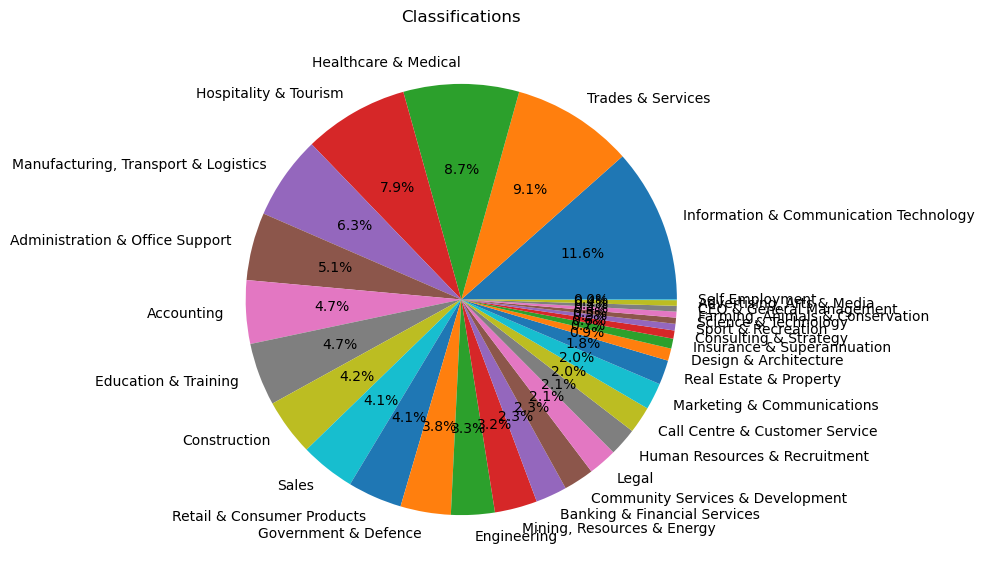

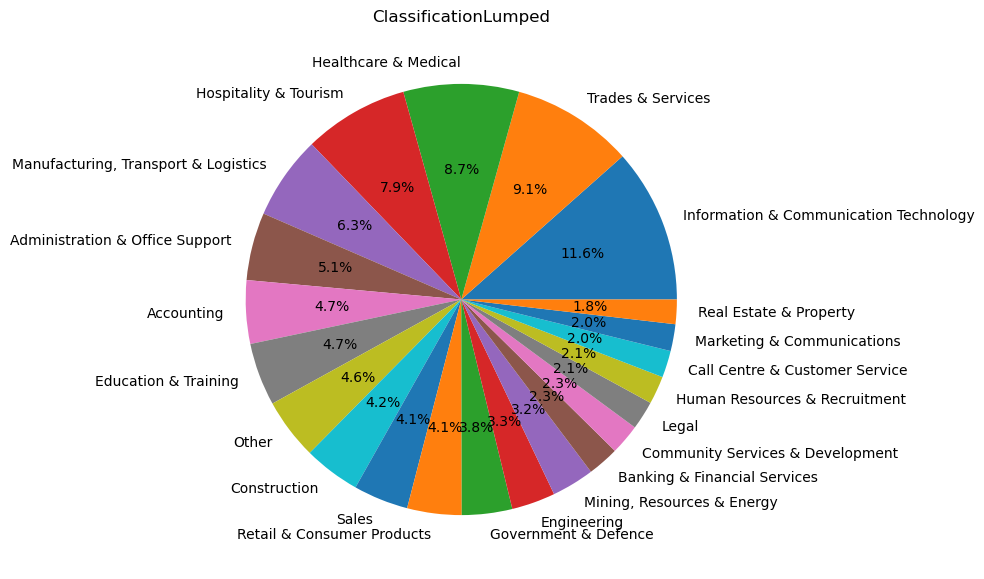

In [21]:
# Calculate the percentage of each classification
classification_counts = df['Classification'].value_counts()
classification_percentages = classification_counts / classification_counts.sum()

# Set the threshold for lumping small classifications
threshold = 0.01  # Set the threshold to 1% (0.01)

# Convert the classification percentages to a DataFrame
classification_percentages_df = pd.DataFrame(classification_percentages)

# Create a new column 'ClassificationLumped' based on the threshold
df['ClassificationLumped'] = df['Classification'].copy()
df.loc[df['Classification'].isin(classification_percentages_df[classification_percentages_df['Classification'] < threshold].index), 'ClassificationLumped'] = 'Other'

# Pie chart of original Classification
plt.figure(figsize=(7, 7))
df['Classification'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Classifications')
plt.ylabel('')
plt.show()

# Pie chart of original ClassificationLumped
plt.figure(figsize=(7, 7))
df['ClassificationLumped'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('ClassificationLumped')
plt.ylabel('')
plt.show()



### Save preprocessed csv

In [39]:
df.to_csv("preprocessed_job-market.csv")